In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
data = pd.read_csv(
    "wdbc.data",
    header=None
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (569, 32)


In [7]:
feature_names = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

columns = ["id", "diagnosis"] + feature_names

data.columns = columns

print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [8]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nDataset information:")
data.info()

Number of rows: 569
Number of columns: 32

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               56

In [9]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [11]:
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [12]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print(data["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


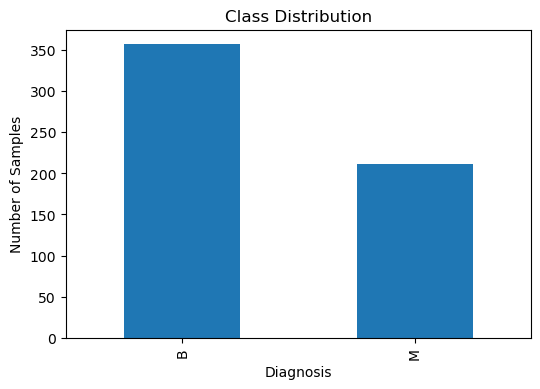

In [18]:
data["diagnosis"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

In [19]:
data["diagnosis"] = data["diagnosis"].map({
    "B": 0,
    "M": 1
})

print(data["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [20]:
X = data.drop(
    columns=["id", "diagnosis"]
)

y = data["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


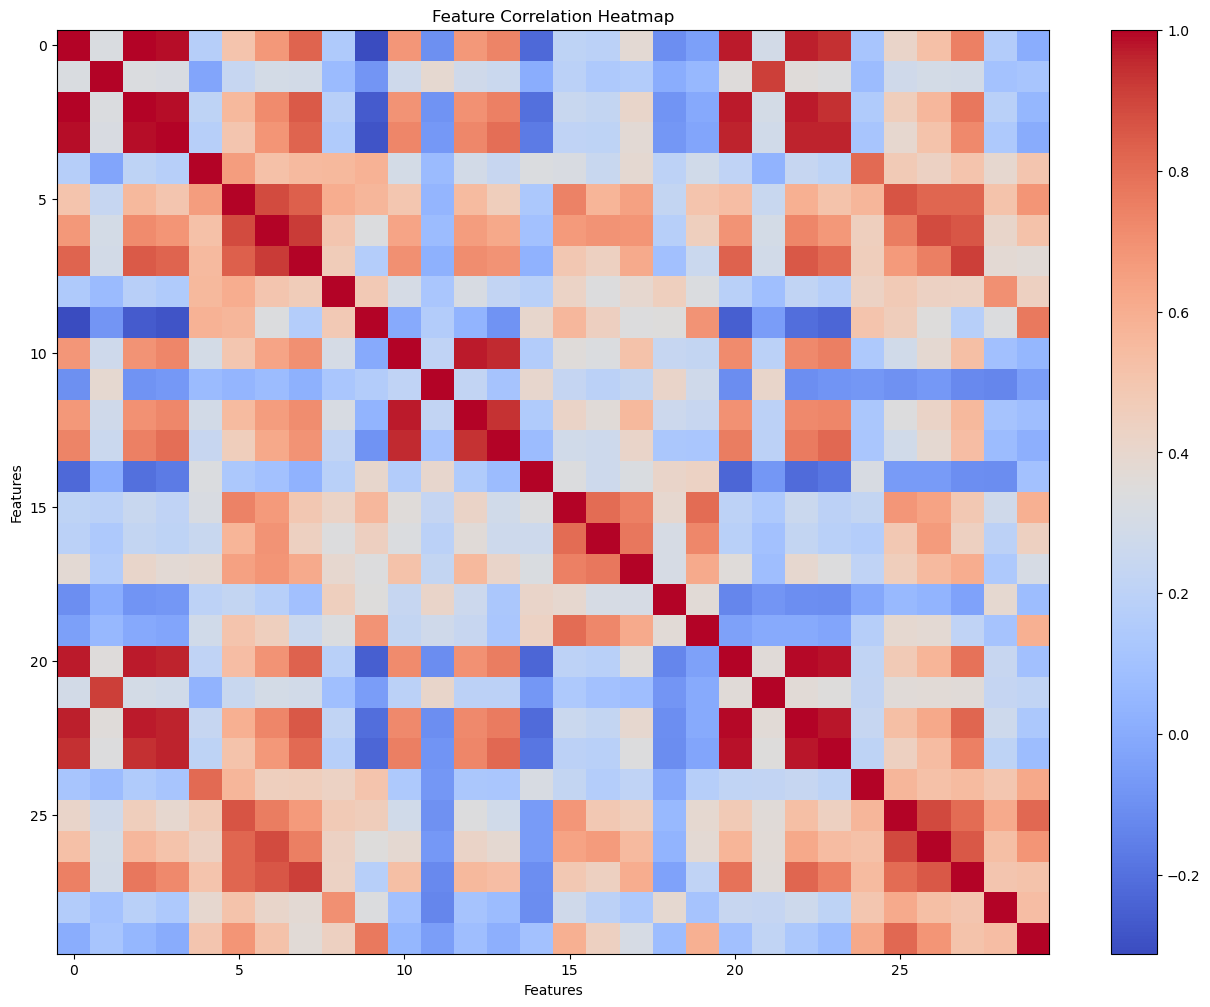

In [21]:
correlation_matrix = X.corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.title("Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (455, 30)
Testing set : (114, 30)


In [23]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [24]:
y_pred_dt = dt_model.predict(X_test)

print("Predictions:")
print(y_pred_dt)

Predictions:
[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 1 1]


In [25]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.9298245614035088
Precision: 0.9047619047619048
Recall   : 0.9047619047619048
F1 Score : 0.9047619047619048


In [26]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



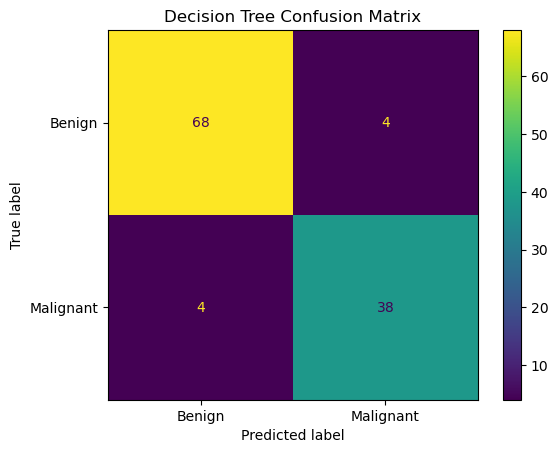

In [27]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

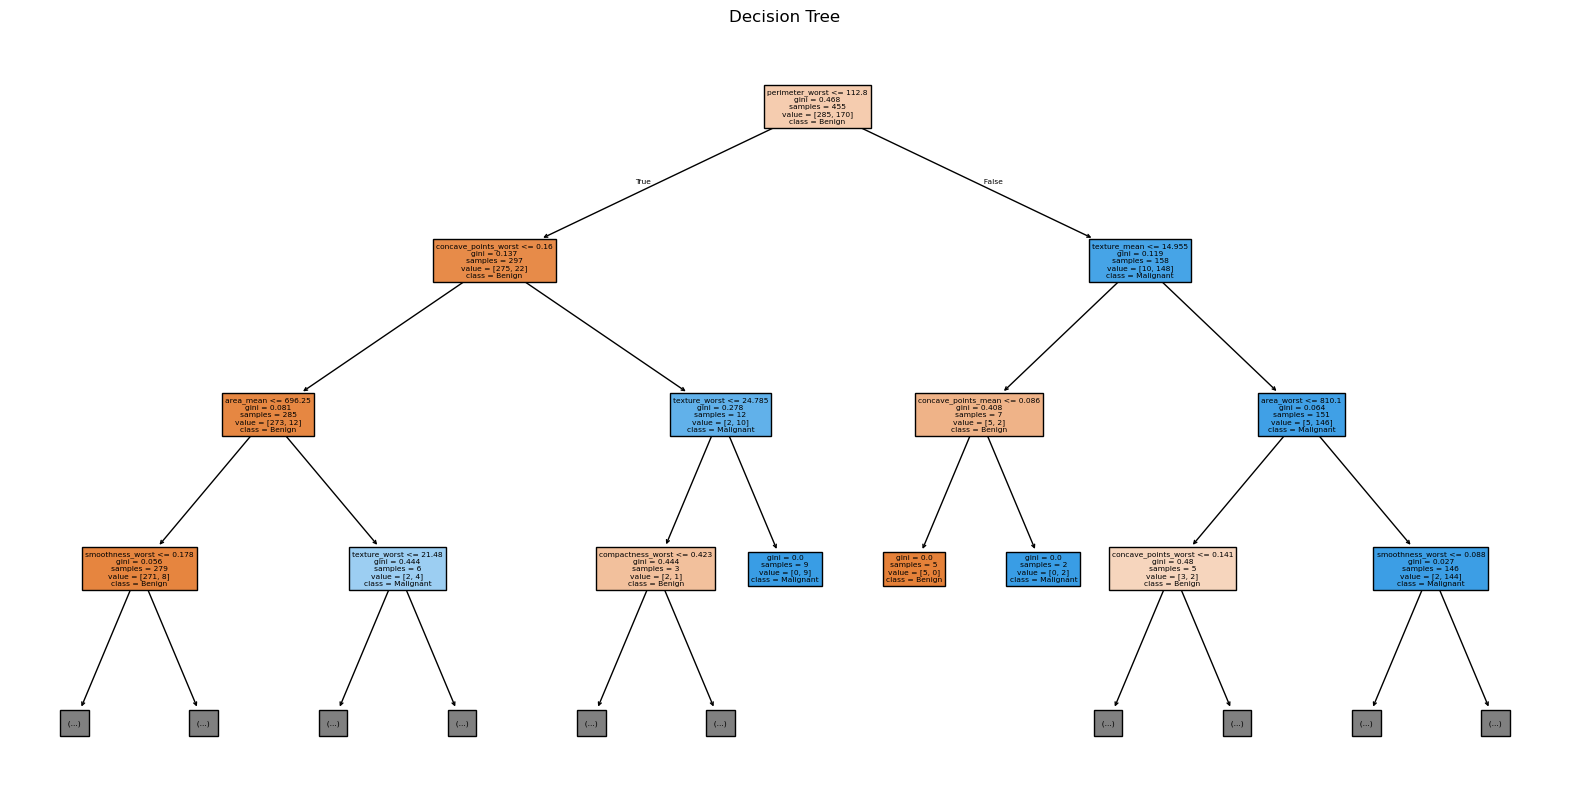

In [28]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree")

plt.show()

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created successfully!")

5-Fold Cross-Validation created successfully!


In [30]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

print("Decision Tree parameter grid:")
print(dt_param_grid)

Decision Tree parameter grid:
{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [33]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree hyperparameter tuning completed!")

Decision Tree hyperparameter tuning completed!


In [34]:
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Average CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best Average CV Accuracy:
0.9362637362637363


In [35]:
best_dt = dt_grid.best_estimator_

print("Best Decision Tree:")
print(best_dt)

Best Decision Tree:
DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=10, random_state=42)


In [36]:
dt_results = pd.DataFrame(
    dt_grid.cv_results_
)

dt_results = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score"
    ]
]

dt_results = dt_results.sort_values(
    by="mean_test_score",
    ascending=False
)

dt_results.head(10)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score
59,entropy,5,10,2,0.936264
77,entropy,10,10,2,0.934066
86,entropy,None,10,2,0.934066
68,entropy,7,10,2,0.934066
56,entropy,5,10,1,0.929670
31,gini,10,5,2,0.929670
22,gini,7,5,2,0.929670
40,gini,None,5,2,0.929670
84,entropy,None,2,2,0.929670
85,entropy,None,5,2,0.929670


In [37]:
dt_results.columns = [
    "Criterion",
    "Max Depth",
    "Min Samples Split",
    "Min Samples Leaf",
    "Avg CV Accuracy"
]

dt_results.head(10)

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy
59,entropy,5,10,2,0.936264
77,entropy,10,10,2,0.934066
86,entropy,None,10,2,0.934066
68,entropy,7,10,2,0.934066
56,entropy,5,10,1,0.929670
31,gini,10,5,2,0.929670
22,gini,7,5,2,0.929670
40,gini,None,5,2,0.929670
84,entropy,None,2,2,0.929670
85,entropy,None,5,2,0.929670


In [38]:
dt_f1_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Decision Tree F1 Scores for 5 Folds:")
print(dt_f1_scores)

print("\nAverage CV F1 Score:")
print(dt_f1_scores.mean())

Decision Tree F1 Scores for 5 Folds:
[0.86567164 0.94117647 0.875      0.93939394 0.93939394]

Average CV F1 Score:
0.9121271982334317


In [39]:
best_dt.fit(
    X_train,
    y_train
)

print("Optimized Decision Tree trained successfully!")

Optimized Decision Tree trained successfully!


In [40]:
y_pred_best_dt = best_dt.predict(
    X_test
)

print("Optimized Decision Tree predictions generated!")

Optimized Decision Tree predictions generated!


In [41]:
best_dt_accuracy = accuracy_score(
    y_test,
    y_pred_best_dt
)

best_dt_precision = precision_score(
    y_test,
    y_pred_best_dt
)

best_dt_recall = recall_score(
    y_test,
    y_pred_best_dt
)

best_dt_f1 = f1_score(
    y_test,
    y_pred_best_dt
)

print("Optimized Decision Tree")
print("----------------------")
print("Accuracy :", best_dt_accuracy)
print("Precision:", best_dt_precision)
print("Recall   :", best_dt_recall)
print("F1 Score :", best_dt_f1)

Optimized Decision Tree
----------------------
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95


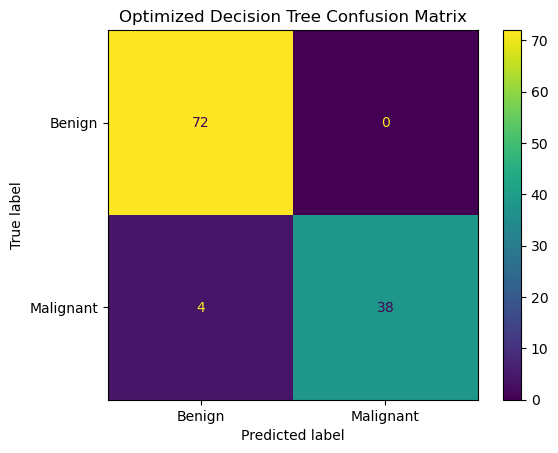

In [42]:
cm_best_dt = confusion_matrix(
    y_test,
    y_pred_best_dt
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_dt,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Optimized Decision Tree Confusion Matrix")

plt.show()

In [43]:
print(
    classification_report(
        y_test,
        y_pred_best_dt,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [44]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [45]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [46]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1 Score : 0.9629629629629629


In [47]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



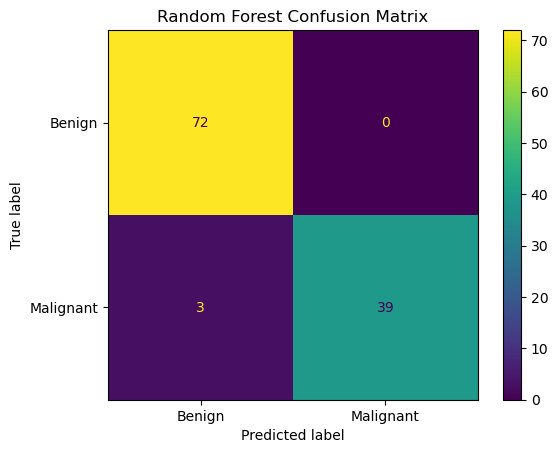

In [48]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [9]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

print("Random Forest parameter grid:")
print(rf_param_grid)

Random Forest parameter grid:
{'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10], 'max_features': ['sqrt', 'log2'], 'bootstrap': [True, False]}


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Random Forest libraries imported!")

Random Forest libraries imported!


In [12]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created!")

5-Fold Cross-Validation created!


In [13]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

print("Random Forest parameter grid created!")

Random Forest parameter grid created!


In [18]:
import pandas as pd

data = pd.read_csv(
    "wdbc.data",
    header=None
)

print("Dataset loaded!")
print("Shape:", data.shape)

Dataset loaded!
Shape: (569, 32)


In [19]:
feature_names = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

data.columns = ["id", "diagnosis"] + feature_names

print(data.shape)
print(data.head())

(569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst

In [20]:
data["diagnosis"] = data["diagnosis"].map({
    "B": 0,
    "M": 1
})

print(data["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [21]:
X = data.drop(
    columns=["id", "diagnosis"]
)

y = data["diagnosis"]

print("X:", X.shape)
print("y:", y.shape)

X: (569, 30)
y: (569,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (455, 30)
Testing : (114, 30)


In [23]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold CV ready!")

5-Fold CV ready!


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

print("Random Forest settings ready!")

Random Forest settings ready!


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Imports successful!")

Imports successful!


In [15]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("cv created successfully!")

cv created successfully!


In [16]:
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [20]:
import pandas as pd

data = pd.read_csv(
    "wdbc.data",
    header=None
)

print("Dataset loaded!")
print("Shape:", data.shape)

Dataset loaded!
Shape: (569, 32)


In [21]:
feature_names = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

data.columns = ["id", "diagnosis"] + feature_names

print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [22]:
data["diagnosis"] = data["diagnosis"].map({
    "B": 0,
    "M": 1
})

print(data["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [23]:
X = data.drop(columns=["id", "diagnosis"])
y = data["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (455, 30)
X_test : (114, 30)


In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold CV created!")

5-Fold CV created!


In [5]:
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

print("Parameter grid ready!")

Parameter grid ready!


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Imports successful!")

Imports successful!


In [7]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
import pandas as pd

data = pd.read_csv(
    "wdbc.data",
    header=None
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (569, 32)


In [12]:
# Add column names

feature_names = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

data.columns = ["id", "diagnosis"] + feature_names

# Encode target
data["diagnosis"] = data["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Create X and y
X = data.drop(columns=["id", "diagnosis"])
y = data["diagnosis"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X:", X.shape)
print("y:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X: (569, 30)
y: (569,)
X_train: (455, 30)
X_test: (114, 30)


In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest hyperparameter tuning completed!")

Random Forest hyperparameter tuning completed!


In [22]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Average CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Best Average CV Accuracy:
0.9670329670329672


In [23]:
best_rf = rf_grid.best_estimator_

print("Best Random Forest:")
print(best_rf)

Best Random Forest:
RandomForestClassifier(max_depth=5, random_state=42)


In [24]:
rf_results = pd.DataFrame(
    rf_grid.cv_results_
)

rf_results = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_bootstrap",
        "mean_test_score"
    ]
]

rf_results = rf_results.sort_values(
    by="mean_test_score",
    ascending=False
)

rf_results.head(10)

,param_n_estimators,param_max_depth,param_max_features,param_bootstrap,mean_test_score
1,100,5,sqrt,True,0.967033
5,100,10,sqrt,True,0.964835
9,100,None,sqrt,True,0.964835
7,100,10,log2,True,0.964835
11,100,None,log2,True,0.964835
0,50,5,sqrt,True,0.962637
4,50,10,sqrt,True,0.960440
8,50,None,sqrt,True,0.960440
3,100,5,log2,True,0.960440
6,50,10,log2,True,0.960440


In [26]:
rf_results.columns = [
    "N Estimators",
    "Max Depth",
    "Max Features",
    "Bootstrap",
    "Avg CV Accuracy"
]

rf_results.head(10)

,N Estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy
1,100,5,sqrt,True,0.967033
5,100,10,sqrt,True,0.964835
9,100,None,sqrt,True,0.964835
7,100,10,log2,True,0.964835
11,100,None,log2,True,0.964835
0,50,5,sqrt,True,0.962637
4,50,10,sqrt,True,0.960440
8,50,None,sqrt,True,0.960440
3,100,5,log2,True,0.960440
6,50,10,log2,True,0.960440


In [28]:
from sklearn.model_selection import cross_val_score

print("cross_val_score imported!")

cross_val_score imported!


In [29]:
rf_f1_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Random Forest F1 Scores:")
print(rf_f1_scores)

print("\nAverage CV F1 Score:")
print(rf_f1_scores.mean())

Random Forest F1 Scores:
[0.95522388 1.         0.92307692 0.92753623 0.97058824]

Average CV F1 Score:
0.9552850541704228


In [30]:
best_rf.fit(
    X_train,
    y_train
)

print("Optimized Random Forest trained successfully!")

Optimized Random Forest trained successfully!


In [31]:
y_pred_best_rf = best_rf.predict(
    X_test
)

print("Optimized Random Forest predictions generated!")

Optimized Random Forest predictions generated!


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Metrics imported successfully!")

Metrics imported successfully!


In [35]:
best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_precision = precision_score(
    y_test,
    y_pred_best_rf
)

best_rf_recall = recall_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf
)

print("Optimized Random Forest")
print("-----------------------")
print("Accuracy :", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall   :", best_rf_recall)
print("F1 Score :", best_rf_f1)

Optimized Random Forest
-----------------------
Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1 Score : 0.9629629629629629


In [38]:
# All required imports for the remaining assignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("All required libraries imported successfully!")

All required libraries imported successfully!


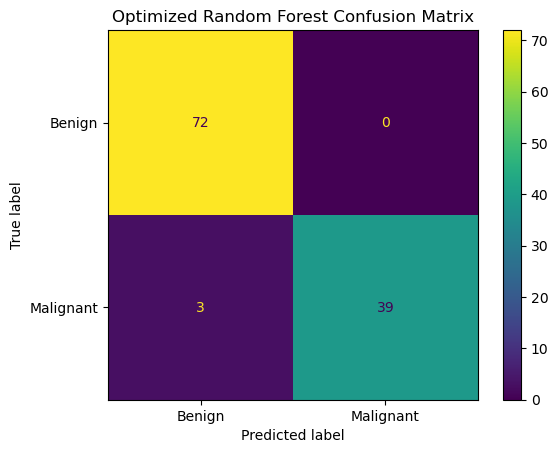

In [39]:
cm_best_rf = confusion_matrix(
    y_test,
    y_pred_best_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_rf,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Optimized Random Forest Confusion Matrix")

plt.show()

In [40]:
print(
    classification_report(
        y_test,
        y_pred_best_rf,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

print("Decision Tree tools imported!")

Decision Tree tools imported!


In [43]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

print("Decision Tree parameter grid created!")

Decision Tree parameter grid created!


In [44]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [52]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree tuning completed!")

Decision Tree tuning completed!


In [51]:
best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best CV Accuracy:
0.9362637362637363


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_best_dt = best_dt.predict(X_test)

best_dt_accuracy = accuracy_score(
    y_test,
    y_pred_best_dt
)

best_dt_precision = precision_score(
    y_test,
    y_pred_best_dt
)

best_dt_recall = recall_score(
    y_test,
    y_pred_best_dt
)

best_dt_f1 = f1_score(
    y_test,
    y_pred_best_dt
)

print("Optimized Decision Tree")
print("-----------------------")
print("Accuracy :", best_dt_accuracy)
print("Precision:", best_dt_precision)
print("Recall   :", best_dt_recall)
print("F1 Score :", best_dt_f1)

Optimized Decision Tree
-----------------------
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95


In [54]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# Create 5 folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

for fold, (train_index, val_index) in enumerate(
    cv.split(X_train, y_train), start=1
):

    # Split training data into fold-training and fold-validation
    X_fold_train = X_train.iloc[train_index]
    X_fold_val = X_train.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    # Decision Tree
    dt_fold = best_dt
    dt_fold.fit(X_fold_train, y_fold_train)

    dt_pred = dt_fold.predict(X_fold_val)

    dt_acc = accuracy_score(
        y_fold_val,
        dt_pred
    )

    dt_f1 = f1_score(
        y_fold_val,
        dt_pred
    )

    # Random Forest
    rf_fold = best_rf
    rf_fold.fit(X_fold_train, y_fold_train)

    rf_pred = rf_fold.predict(X_fold_val)

    rf_acc = accuracy_score(
        y_fold_val,
        rf_pred
    )

    rf_f1 = f1_score(
        y_fold_val,
        rf_pred
    )

    fold_results.append([
        fold,
        dt_acc,
        dt_f1,
        rf_acc,
        rf_f1
    ])

fold_comparison = pd.DataFrame(
    fold_results,
    columns=[
        "Fold",
        "Decision Tree Accuracy",
        "Decision Tree F1",
        "Random Forest Accuracy",
        "Random Forest F1"
    ]
)

fold_comparison

,Fold,Decision Tree Accuracy,Decision Tree F1,Random Forest Accuracy,Random Forest F1
0,1,0.901099,0.865672,0.967033,0.955224
1,2,0.956044,0.941176,1.000000,1.000000
2,3,0.912088,0.875000,0.945055,0.923077
3,4,0.956044,0.939394,0.945055,0.927536
4,5,0.956044,0.939394,0.978022,0.970588


In [55]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        best_dt_accuracy,
        best_rf_accuracy
    ],
    
    "Precision": [
        best_dt_precision,
        best_rf_precision
    ],
    
    "Recall": [
        best_dt_recall,
        best_rf_recall
    ],
    
    "F1 Score": [
        best_dt_f1,
        best_rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.964912,1.0,0.904762,0.950000
1,Random Forest,0.973684,1.0,0.928571,0.962963


In [56]:
dt_prob = best_dt.predict_proba(X_test)[:, 1]

rf_prob = best_rf.predict_proba(X_test)[:, 1]

In [57]:
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

In [58]:
dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Decision Tree AUC :", dt_auc)
print("Random Forest AUC :", rf_auc)

Decision Tree AUC : 0.9546957671957672
Random Forest AUC : 0.992063492063492


In [59]:
dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Decision Tree AUC :", dt_auc)
print("Random Forest AUC :", rf_auc)

Decision Tree AUC : 0.9546957671957672
Random Forest AUC : 0.992063492063492


In [60]:
final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        best_dt_accuracy,
        best_rf_accuracy
    ],
    
    "Precision": [
        best_dt_precision,
        best_rf_precision
    ],
    
    "Recall": [
        best_dt_recall,
        best_rf_recall
    ],
    
    "F1 Score": [
        best_dt_f1,
        best_rf_f1
    ],
    
    "AUC": [
        dt_auc,
        rf_auc
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Decision Tree,0.964912,1.0,0.904762,0.950000,0.954696
1,Random Forest,0.973684,1.0,0.928571,0.962963,0.992063
